In [1]:
!pip install torch-pruning scipy tqdm matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.7 MB/s eta 0:00:00


In [2]:

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torchvision.models import vgg16
from tqdm import tqdm
import numpy as np
from scipy.stats import spearmanr
import copy
import torch_pruning as tp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

sns.set_style("darkgrid")

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 128
EPOCHS_PRETRAIN = 100
EPOCHS_FINETUNE = 100
PRUNE_RATIO = 0.3

CALIB_SAMPLES = 2000
ORACLE_BATCHES = 5

LR = 0.01
WEIGHT_DECAY = 5e-4

print("Device:", DEVICE)

Device: cuda


In [4]:
train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914,0.4822,0.4465),
                (0.2470,0.2435,0.2616))
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914,0.4822,0.4465),
                (0.2470,0.2435,0.2616))
])

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_tf
)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_tf
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 170M/170M [00:05<00:00, 32.7MB/s]


In [5]:
model = vgg16(num_classes=10)

# CIFAR fix
model.features[0] = nn.Conv2d(3, 64, 3, 1, 1)
model.features[4] = nn.Identity()

# CRITICAL FIX
model.avgpool = nn.AdaptiveAvgPool2d((1,1))

# Classifier
model.classifier = nn.Sequential(
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 100)
)

# Remove inplace bug
def remove_inplace_relu(model):
    for m in model.modules():
        if isinstance(m, nn.ReLU):
            m.inplace = False

remove_inplace_relu(model)

model = model.to(DEVICE)

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(), lr=LR,
    momentum=0.9, weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[25,35], gamma=0.1)

train_acc_list = []
test_acc_list = []

In [7]:
def evaluate(model):
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total

In [8]:
best_acc = 0

for epoch in range(EPOCHS_PRETRAIN):
    model.train()

    for x,y in train_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        optimizer.step()

    scheduler.step()

    acc = evaluate(model)
    test_acc_list.append(acc)

    print(f"Epoch {epoch+1} | Acc {acc*100:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(),
                   "/kaggle/working/vgg16_baseline_best.pt")

Epoch 1 | Acc 23.36%
Epoch 2 | Acc 35.41%
Epoch 3 | Acc 48.85%
Epoch 4 | Acc 58.02%
Epoch 5 | Acc 63.17%
Epoch 6 | Acc 65.88%
Epoch 7 | Acc 70.25%
Epoch 8 | Acc 73.84%
Epoch 9 | Acc 76.29%
Epoch 10 | Acc 74.76%
Epoch 11 | Acc 79.53%
Epoch 12 | Acc 81.34%
Epoch 13 | Acc 82.65%
Epoch 14 | Acc 82.19%
Epoch 15 | Acc 81.47%
Epoch 16 | Acc 85.94%
Epoch 17 | Acc 82.01%
Epoch 18 | Acc 86.81%
Epoch 19 | Acc 86.73%
Epoch 20 | Acc 85.95%
Epoch 21 | Acc 85.74%
Epoch 22 | Acc 86.75%
Epoch 23 | Acc 86.93%
Epoch 24 | Acc 88.19%
Epoch 25 | Acc 87.12%
Epoch 26 | Acc 90.27%
Epoch 27 | Acc 90.34%
Epoch 28 | Acc 90.44%
Epoch 29 | Acc 90.83%
Epoch 30 | Acc 90.49%
Epoch 31 | Acc 90.68%
Epoch 32 | Acc 90.63%
Epoch 33 | Acc 90.64%
Epoch 34 | Acc 90.94%
Epoch 35 | Acc 90.78%
Epoch 36 | Acc 90.75%
Epoch 37 | Acc 90.89%
Epoch 38 | Acc 90.82%
Epoch 39 | Acc 90.84%
Epoch 40 | Acc 90.80%
Epoch 41 | Acc 90.84%
Epoch 42 | Acc 90.84%
Epoch 43 | Acc 90.82%
Epoch 44 | Acc 90.84%
Epoch 45 | Acc 90.88%
Epoch 46 | Acc 90.8

[]
[0.2336, 0.3541, 0.4885, 0.5802, 0.6317, 0.6588, 0.7025, 0.7384, 0.7629, 0.7476, 0.7953, 0.8134, 0.8265, 0.8219, 0.8147, 0.8594, 0.8201, 0.8681, 0.8673, 0.8595, 0.8574, 0.8675, 0.8693, 0.8819, 0.8712, 0.9027, 0.9034, 0.9044, 0.9083, 0.9049, 0.9068, 0.9063, 0.9064, 0.9094, 0.9078, 0.9075, 0.9089, 0.9082, 0.9084, 0.908, 0.9084, 0.9084, 0.9082, 0.9084, 0.9088, 0.9089, 0.9082, 0.9089, 0.9082, 0.9076, 0.9074, 0.9069, 0.9083, 0.9083, 0.9081, 0.9075, 0.9086, 0.9084, 0.9079, 0.9098, 0.908, 0.9093, 0.91, 0.9091, 0.9081, 0.9089, 0.9089, 0.9086, 0.9076, 0.9092, 0.9093, 0.9093, 0.9089, 0.9091, 0.9087, 0.9086, 0.9087, 0.9097, 0.9089, 0.9083, 0.9075, 0.909, 0.9094, 0.9094, 0.9085, 0.909, 0.9085, 0.9079, 0.9085, 0.909, 0.9074, 0.9087, 0.9083, 0.9083, 0.909, 0.9087, 0.9079, 0.9082, 0.9077, 0.9097]


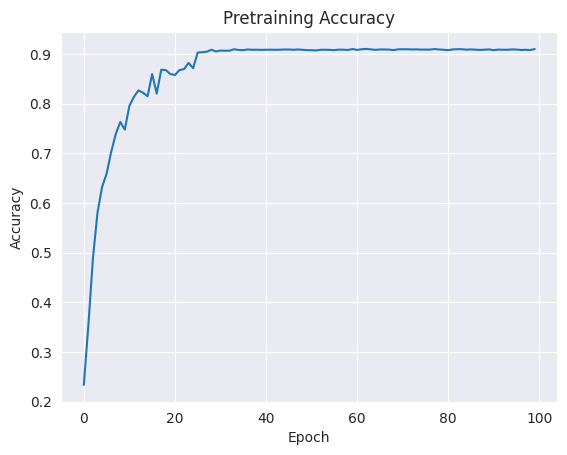

In [9]:
print(train_acc_list)
print(test_acc_list)
plt.plot(test_acc_list)
plt.title("Pretraining Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()